<div align="center">

# Cálculo Numérico — Atividade Prática II
## Estabilidade Numérica e Overflow

**Simulação simplificada de dinâmica dos fluidos computacional**

---

**Aluno(a):** __________________________________________  
**Professor(a):** Prof. Raquel J. Lobosco  
**Data:** 02 de setembro de 2026

</div>

> **Objetivo:** investigar a relação entre passo de tempo, estabilidade numérica e ocorrência de overflow em um esquema explícito de diferenças finitas.

### Roteiro
1. Modelo e condição de estabilidade;
2. Atividade 1 — verificação da estabilidade;
3. Atividade 2 — detecção de overflow;
4. Atividade 3 — crescimento da velocidade;
5. Atividade 4 — `float32` × `float64`.

## 1. Modelo e condição de estabilidade

O problema representa um fluido entre duas placas paralelas separadas por $H=0,01\;m$.  
A placa em $y=0$ move-se com velocidade constante $U=1\;m/s$, enquanto a placa em $y=H$ permanece parada.

A equação utilizada é:

$$
\frac{\partial u}{\partial t}
=
\nu \frac{\partial^2u}{\partial y^2}
$$

com $\nu=10^{-4}\;m^2/s$.

Usando Euler explícito no tempo e diferenças finitas centrais no espaço:

$$
u_i^{n+1}
=
u_i^n
+
r\left(u_{i+1}^n-2u_i^n+u_{i-1}^n\right)
$$

onde

$$
r=\frac{\nu\Delta t}{\Delta y^2}.
$$

Para este método, a condição de estabilidade é:

$$
\boxed{r\leq\frac{1}{2}}
$$

ou, equivalentemente,

$$
\boxed{\Delta t\leq\frac{\Delta y^2}{2\nu}}.
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Constantes físicas
H = 0.01
NU = 1e-4
U = 1.0

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula a difusão de velocidade e detecta overflow/operações inválidas."""

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(NU * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(U)
    u[-1] = tipo(0)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None
    erro = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

                novo[0] = tipo(U)
                novo[-1] = tipo(0)

            except FloatingPointError as exc:
                falha = passo
                erro = str(exc)
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    return {
        "y": y,
        "u": u,
        "tempos": np.asarray(tempos),
        "maximos": np.asarray(maximos),
        "r": float(r),
        "falha": falha,
        "erro": erro,
        "dy": dy,
        "dt": dt,
        "tipo": tipo.__name__,
        "pontos": pontos,
        "tempo_final": tempos[-1],
    }

print("Ambiente carregado com sucesso.")
print(f"Maior float32: {np.finfo(np.float32).max:.3e}")
print(f"Maior float64: {np.finfo(np.float64).max:.3e}")

Ambiente carregado com sucesso.
Maior float32: 3.403e+38
Maior float64: 1.798e+308


## 2. Atividade 1 — Verificação da estabilidade

Para a malha original com 21 pontos:

$$
\Delta y=\frac{H}{21-1}
=\frac{0,01}{20}
=0,0005\;m
$$

e

$$
\Delta t_{\max}
=
\frac{(0,0005)^2}{2(10^{-4})}
=
0,00125\;s.
$$

Agora calculamos $r$ para os dois casos propostos.

In [2]:
pontos_original = 21
dy_original = H / (pontos_original - 1)
dt_max_original = dy_original**2 / (2 * NU)

casos_teoricos = []

for nome, dt in [("Caso A", 0.001), ("Caso B", 0.002)]:
    r = NU * dt / dy_original**2
    classificacao = "Estável" if r <= 0.5 else "Instável"

    casos_teoricos.append({
        "Caso": nome,
        "Δt (s)": dt,
        "Δy (m)": dy_original,
        "r": r,
        "Classificação": classificacao,
    })

tabela_teorica = pd.DataFrame(casos_teoricos)

print(f"Δy = {dy_original:.7f} m")
print(f"Δt máximo = {dt_max_original:.7f} s")

display(
    tabela_teorica.style
    .hide(axis="index")
    .format({
        "Δt (s)": "{:.6f}",
        "Δy (m)": "{:.7f}",
        "r": "{:.1f}",
    })
)

Δy = 0.0005000 m
Δt máximo = 0.0012500 s


Caso,Δt (s),Δy (m),r,Classificação
Caso A,0.001000,0.0005000,0.4,Estável
Caso B,0.002000,0.0005000,0.8,Instável


### Resposta da Atividade 1

- **Caso A:** $r=0,4\leq0,5$. Portanto, o caso é **estável**.
- **Caso B:** $r=0,8>0,5$. Portanto, o caso é **instável**.

A classificação pode ser feita antes mesmo de executar a simulação.

## 3. Atividade 2 — Detecção de overflow

Serão executadas as quatro combinações solicitadas:

- `float32`, $\Delta t=0,001\;s$;
- `float32`, $\Delta t=0,002\;s$;
- `float64`, $\Delta t=0,001\;s$;
- `float64`, $\Delta t=0,002\;s$.

In [3]:
resultados = {}
linhas = []

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        chave = f"{tipo.__name__}, Δt={dt}"
        resultado = simular(
            dt=dt,
            tipo=tipo,
            passos=2000,
            pontos=21,
        )
        resultados[chave] = resultado

        linhas.append({
            "Tipo numérico": tipo.__name__,
            "Δt (s)": dt,
            "r": resultado["r"],
            "Estabilidade": "Estável" if resultado["r"] <= 0.5 else "Instável",
            "Overflow": "Não" if resultado["falha"] is None else "Sim",
            "Iteração da falha": "—" if resultado["falha"] is None else resultado["falha"],
            "Tempo da falha (s)": "—" if resultado["falha"] is None else resultado["falha"] * dt,
        })

tabela_testes = pd.DataFrame(linhas)

display(
    tabela_testes.style
    .hide(axis="index")
    .format({
        "Δt (s)": "{:.3f}",
        "r": "{:.1f}",
    })
)

Tipo numérico,Δt (s),r,Estabilidade,Overflow,Iteração da falha,Tempo da falha (s)
float32,0.001,0.4,Estável,Não,—,—
float32,0.002,0.8,Instável,Sim,121,0.242000
float64,0.001,0.4,Estável,Não,—,—
float64,0.002,0.8,Instável,Sim,917,1.834000


### Resultado observado

O caso estável $(r=0,4)$ completa os 2000 passos sem overflow nos dois tipos numéricos.

No caso instável $(r=0,8)$:

- com `float32`, o overflow aparece no **passo 121**;
- com `float64`, o overflow aparece no **passo 917**.

Isso mostra que **instabilidade numérica e overflow não são a mesma coisa**.  
A instabilidade surge primeiro e faz os valores crescerem de modo não físico. O overflow ocorre depois, quando esses valores ultrapassam a capacidade de representação do tipo numérico.

## 4. Atividade 3 — Crescimento da velocidade

Fisicamente, neste problema a velocidade deve permanecer no intervalo:

$$
0\leq u(y,t)\leq U=1\;m/s.
$$

Logo, qualquer crescimento muito acima de $1\;m/s$ já indica que a solução numérica perdeu o significado físico, mesmo antes de aparecer um overflow.

/opt/pyvenv/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


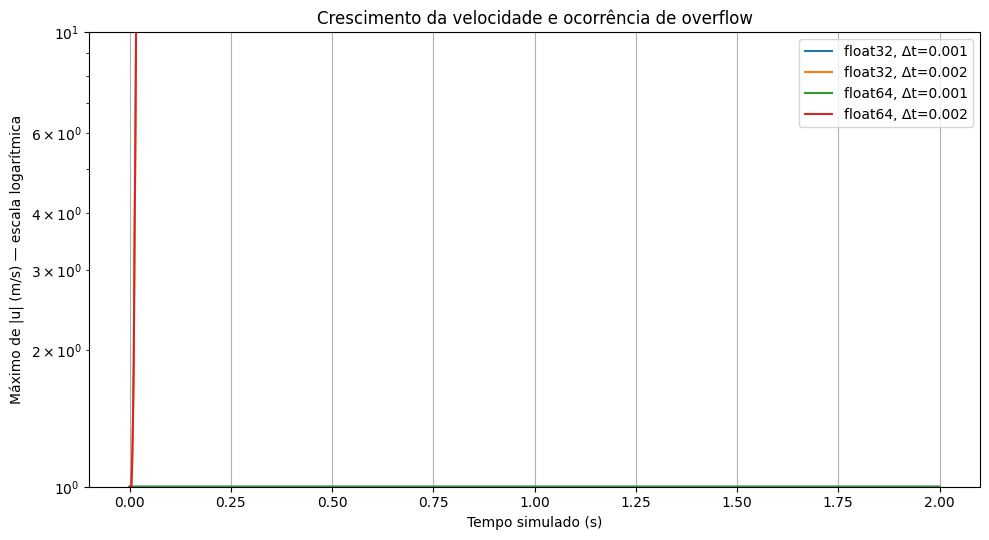

In [4]:
plt.figure(figsize=(10, 5.5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome,
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) — escala logarítmica")
plt.title("Crescimento da velocidade e ocorrência de overflow")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretação física

Quando $0\leq r\leq0,5$, a atualização pode ser escrita como:

$$
u_i^{n+1}
=
r\,u_{i-1}^{n}
+
(1-2r)u_i^n
+
r\,u_{i+1}^{n}.
$$

Os coeficientes são não negativos e somam 1, fazendo a atualização funcionar como uma média ponderada.

No caso instável, $r=0,8$:

$$
1-2r=1-1,6=-0,6.
$$

O coeficiente central torna-se negativo. Pequenas perturbações e erros numéricos podem então ser amplificados a cada iteração, produzindo oscilações e velocidades crescentes que não correspondem à física do problema.

**Conclusão desta etapa:** o crescimento observado é consequência da instabilidade do método, e não de uma aceleração física do fluido.

## 5. Atividade 4 — `float32` × `float64`

Os limites aproximados são:

$$
\text{float32}_{\max}\approx3,4\times10^{38}
\qquad
\text{float64}_{\max}\approx1,8\times10^{308}.
$$

O `float64` consegue representar números muito maiores. Por isso, quando a solução é instável, demora mais até atingir overflow.

Entretanto, trocar `float32` por `float64` **não altera o valor de $r$** e, portanto, **não corrige a condição de estabilidade**.

> **Resposta:** a mudança de tipo numérico apenas adia a falha. A causa da instabilidade continua presente.

### Síntese

| Conceito | Origem | Efeito |
|---|---|---|
| **Instabilidade** | $r > 1/2$ (escolha de $\Delta t$ e $\Delta y$) | amplificação de erros a cada iteração |
| **Overflow** | limite de representação do tipo numérico | interrupção do cálculo, já com solução sem sentido físico |

A instabilidade vem primeiro; o overflow é apenas a sua consequência visível. Corrigi-la exige respeitar $\Delta t \leq \Delta y^2 / (2\nu)$ — não trocar o tipo numérico.

---

<div align="center">

### Fim da atividade

</div>